In [ ]:
import numpy as np 
import pandas as pd 
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats.mstats import winsorize
from sklearn.preprocessing import StandardScaler, OrdinalEncoder, OneHotEncoder

# Dane

In [2]:
data=pd.read_csv("data\\financial_loan.csv")

In [3]:
data.head()

,id,address_state,application_type,emp_length,emp_title,grade,home_ownership,issue_date,last_credit_pull_date,last_payment_date,...,sub_grade,term,verification_status,annual_income,dti,installment,int_rate,loan_amount,total_acc,total_payment
0,1077430,GA,INDIVIDUAL,< 1 year,Ryder,C,RENT,11-02-2021,13-09-2021,13-04-2021,...,C4,60 months,Source Verified,30000.0,0.0100,59.83,0.1527,2500,4,1009
1,1072053,CA,INDIVIDUAL,9 years,MKC Accounting,E,RENT,01-01-2021,14-12-2021,15-01-2021,...,E1,36 months,Source Verified,48000.0,0.0535,109.43,0.1864,3000,4,3939
2,1069243,CA,INDIVIDUAL,4 years,Chemat Technology Inc,C,RENT,05-01-2021,12-12-2021,09-01-2021,...,C5,36 months,Not Verified,50000.0,0.2088,421.65,0.1596,12000,11,3522
3,1041756,TX,INDIVIDUAL,< 1 year,barnes distribution,B,MORTGAGE,25-02-2021,12-12-2021,12-03-2021,...,B2,60 months,Source Verified,42000.0,0.0540,97.06,0.1065,4500,9,4911
4,1068350,IL,INDIVIDUAL,10+ years,J&J Steel Inc,A,MORTGAGE,01-01-2021,14-12-2021,15-01-2021,...,A1,36 months,Verified,83000.0,0.0231,106.53,0.0603,3500,28,3835


In [4]:
data.columns

Index(['id', 'address_state', 'application_type', 'emp_length', 'emp_title',
       'grade', 'home_ownership', 'issue_date', 'last_credit_pull_date',
       'last_payment_date', 'loan_status', 'next_payment_date', 'member_id',
       'purpose', 'sub_grade', 'term', 'verification_status', 'annual_income',
       'dti', 'installment', 'int_rate', 'loan_amount', 'total_acc',
       'total_payment'],
      dtype='object')

## Opis kolumn
- id - identyfikator klienta/wniosku
- address_state - stan zamieszkania
- application_type - typ aplikacji **(zawiera tylko wartość INDIVIDUAL)**
- emp_length - długość zatrudnienia w latach
- emp_title - stanowisko prcay
- grade - ocena kredytowa **(A-G im wyższa tym lepiej)**
- home_ownership - status posiadania domu **(RENT, MORTAGE, OWN, OTHER, NONE)**
- issue_date - data wydania pożyczki
- last_credit_pull_date - data ostatniego sprawdzenia historii kredytowej
- last_payment_date - data ostatniej wpłaty na pożyczkę
- loan_status - status pożyczki **(Fully_Paid, Charged Off, Current)**
- next_payment_date - planowana data następnej wpłaty
- member_id - identyfikator klienta
- purpose - cel pożyczki **(13 kategorii plus other)**
- sub_grade - podkategoria oceny kredytowej **(bardziej dokładna niż grade, typu A1, A2, ...)**
- term - okres spłaty pożyczki **(36 months, 60 months)**
- verification_status - status weryfikacji dochodu klienta **(Not Verified, Verified, Source Verified)**
- annual_income - roczny dochód klienta
- dti (dent-to-income-ratio) - wskaźnik zadłużenia do dochodu
- installment - miesięczna rata
- int_rate - oprocentowanie
- loan_amount - kwota pożyczki
- total_acc - łączna liczba kont kredytowych klienta'
- total_payment - łączna suma spłat dokonanych przez klienta

## Cel biznesowy 
- Wykrywanie wzorców niespłacania w celu możliwości wykorzystania ich do poprawy procesów windykacyjnych przez zrozumienie charakterystyk klastrów o wysokim ryzyku.

W związku z wyborem celu biznesowego pozbywany się poniższych kolumn.

In [5]:
data = data.drop(['int_rate', 'grade', 'sub_grade'], axis=1)

## Analiza

In [6]:
data.info() #none pojawia się w kolumnie emp_title

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 38576 entries, 0 to 38575
Data columns (total 21 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   id                     38576 non-null  int64  
 1   address_state          38576 non-null  object 
 2   application_type       38576 non-null  object 
 3   emp_length             38576 non-null  object 
 4   emp_title              37138 non-null  object 
 5   home_ownership         38576 non-null  object 
 6   issue_date             38576 non-null  object 
 7   last_credit_pull_date  38576 non-null  object 
 8   last_payment_date      38576 non-null  object 
 9   loan_status            38576 non-null  object 
 10  next_payment_date      38576 non-null  object 
 11  member_id              38576 non-null  int64  
 12  purpose                38576 non-null  object 
 13  term                   38576 non-null  object 
 14  verification_status    38576 non-null  object 
 15  an

Jedynie kolumna emp_title zawiera none, które mogą świadczyć o brKu zatrudnienia danej osoby.

In [7]:
data.describe()

,id,member_id,annual_income,dti,installment,loan_amount,total_acc,total_payment
count,3.857600e+04,3.857600e+04,3.857600e+04,38576.000000,38576.000000,38576.000000,38576.000000,38576.000000
mean,6.810371e+05,8.476515e+05,6.964454e+04,0.133274,326.862965,11296.066855,22.132544,12263.348533
std,2.113246e+05,2.668105e+05,6.429368e+04,0.066662,209.092000,7460.746022,11.392282,9051.104777
min,5.473400e+04,7.069900e+04,4.000000e+03,0.000000,15.690000,500.000000,2.000000,34.000000
25%,5.135170e+05,6.629788e+05,4.150000e+04,0.082100,168.450000,5500.000000,14.000000,5633.000000
50%,6.627280e+05,8.473565e+05,6.000000e+04,0.134200,283.045000,10000.000000,20.000000,10042.000000
75%,8.365060e+05,1.045652e+06,8.320050e+04,0.185900,434.442500,15000.000000,29.000000,16658.000000
max,1.077501e+06,1.314167e+06,6.000000e+06,0.299900,1305.190000,35000.000000,90.000000,58564.000000


In [8]:
data.nunique()

id                       38576
address_state               50
application_type             1
emp_length                  11
emp_title                28525
home_ownership               5
issue_date                  65
last_credit_pull_date      107
last_payment_date          102
loan_status                  3
next_payment_date          102
member_id                38576
purpose                     14
term                         2
verification_status          3
annual_income             5096
dti                       2863
installment              15132
loan_amount                880
total_acc                   82
total_payment            19525
dtype: int64

In [9]:
columns = ['application_type', 'emp_length',
         'home_ownership', 'loan_status',
       'purpose', 'term', 'verification_status']
for col in columns:
    print(f"Unique values in {col}:")
    print(data[col].value_counts())
    print("\n")

Unique values in application_type:
application_type
INDIVIDUAL    38576
Name: count, dtype: int64


Unique values in emp_length:
emp_length
10+ years    8870
< 1 year     4575
2 years      4382
3 years      4088
4 years      3428
5 years      3273
1 year       3229
6 years      2228
7 years      1772
8 years      1476
9 years      1255
Name: count, dtype: int64


Unique values in home_ownership:
home_ownership
RENT        18439
MORTGAGE    17198
OWN          2838
OTHER          98
NONE            3
Name: count, dtype: int64


Unique values in loan_status:
loan_status
Fully Paid     32145
Charged Off     5333
Current         1098
Name: count, dtype: int64


Unique values in purpose:
purpose
Debt consolidation    18214
credit card            4998
other                  3824
home improvement       2876
major purchase         2110
small business         1776
car                    1497
wedding                 928
medical                 667
moving                  559
house                

In [10]:
mask = data['emp_title'].map(data['emp_title'].value_counts()) > 34
data.loc[mask, 'emp_title'].value_counts()

emp_title
US Army                    135
Bank of America            109
IBM                         67
AT&T                        63
Wells Fargo                 57
Kaiser Permanente           56
USAF                        55
UPS                         52
US Air Force                52
Walmart                     45
Lockheed Martin             44
United States Air Force     42
State of California         42
U.S. Army                   42
Verizon Wireless            41
Self Employed               40
USPS                        40
US ARMY                     39
Walgreens                   38
JP Morgan Chase             38
US Navy                     37
Department of Defense       36
JPMorgan Chase              36
Target                      35
Self                        35
Name: count, dtype: int64

In [11]:
sum(data['emp_title'].value_counts()==1) #tyle nazw stanowisk pojawia się tylko raz

25309

In [12]:
np.divide(data['emp_title'].isnull().sum(), data['emp_title'].count()) #braki danych prawie 4%


np.float64(0.038720448058592274)

Kolumna emp_title zawiera bardzo dużo różnych nazw, stąd jedynie wykorzystamy informację o tym czy ktoś jest zatrudniony czy nie.

In [13]:
data['is_employed'] = np.where(data['emp_title'].isnull(), 0, 1)
data = data.drop('emp_title', axis=1)
data.head()


,id,address_state,application_type,emp_length,home_ownership,issue_date,last_credit_pull_date,last_payment_date,loan_status,next_payment_date,...,purpose,term,verification_status,annual_income,dti,installment,loan_amount,total_acc,total_payment,is_employed
0,1077430,GA,INDIVIDUAL,< 1 year,RENT,11-02-2021,13-09-2021,13-04-2021,Charged Off,13-05-2021,...,car,60 months,Source Verified,30000.0,0.0100,59.83,2500,4,1009,1
1,1072053,CA,INDIVIDUAL,9 years,RENT,01-01-2021,14-12-2021,15-01-2021,Fully Paid,15-02-2021,...,car,36 months,Source Verified,48000.0,0.0535,109.43,3000,4,3939,1
2,1069243,CA,INDIVIDUAL,4 years,RENT,05-01-2021,12-12-2021,09-01-2021,Charged Off,09-02-2021,...,car,36 months,Not Verified,50000.0,0.2088,421.65,12000,11,3522,1
3,1041756,TX,INDIVIDUAL,< 1 year,MORTGAGE,25-02-2021,12-12-2021,12-03-2021,Fully Paid,12-04-2021,...,car,60 months,Source Verified,42000.0,0.0540,97.06,4500,9,4911,1
4,1068350,IL,INDIVIDUAL,10+ years,MORTGAGE,01-01-2021,14-12-2021,15-01-2021,Fully Paid,15-02-2021,...,car,36 months,Verified,83000.0,0.0231,106.53,3500,28,3835,1


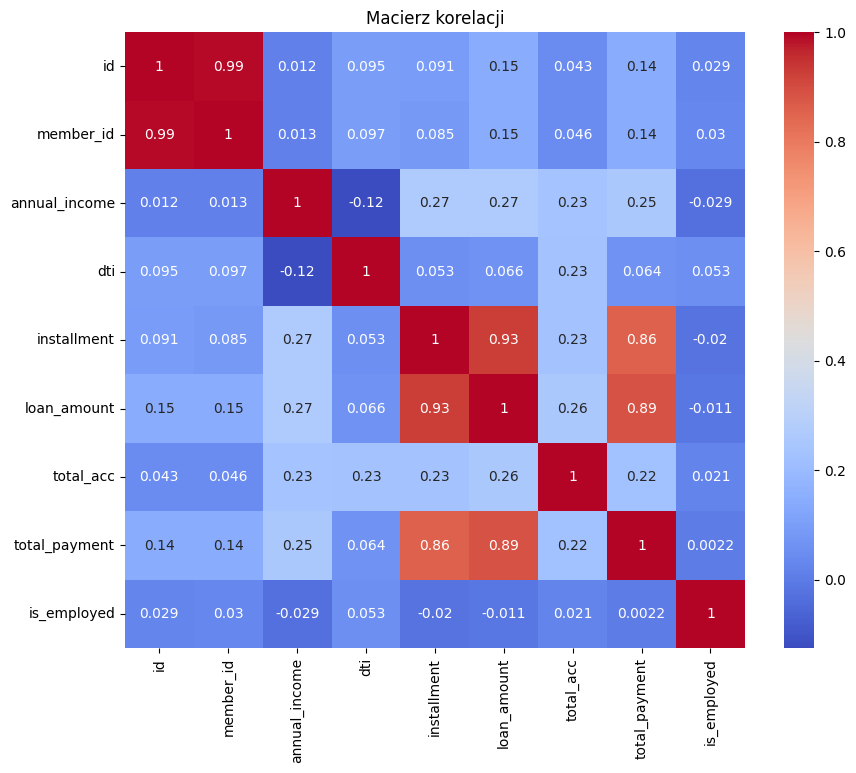

In [14]:
plt.figure(figsize=(10,8))
sns.heatmap(data.select_dtypes(include=np.number).corr(), annot=True, cmap='coolwarm')
plt.title('Macierz korelacji')
plt.show()

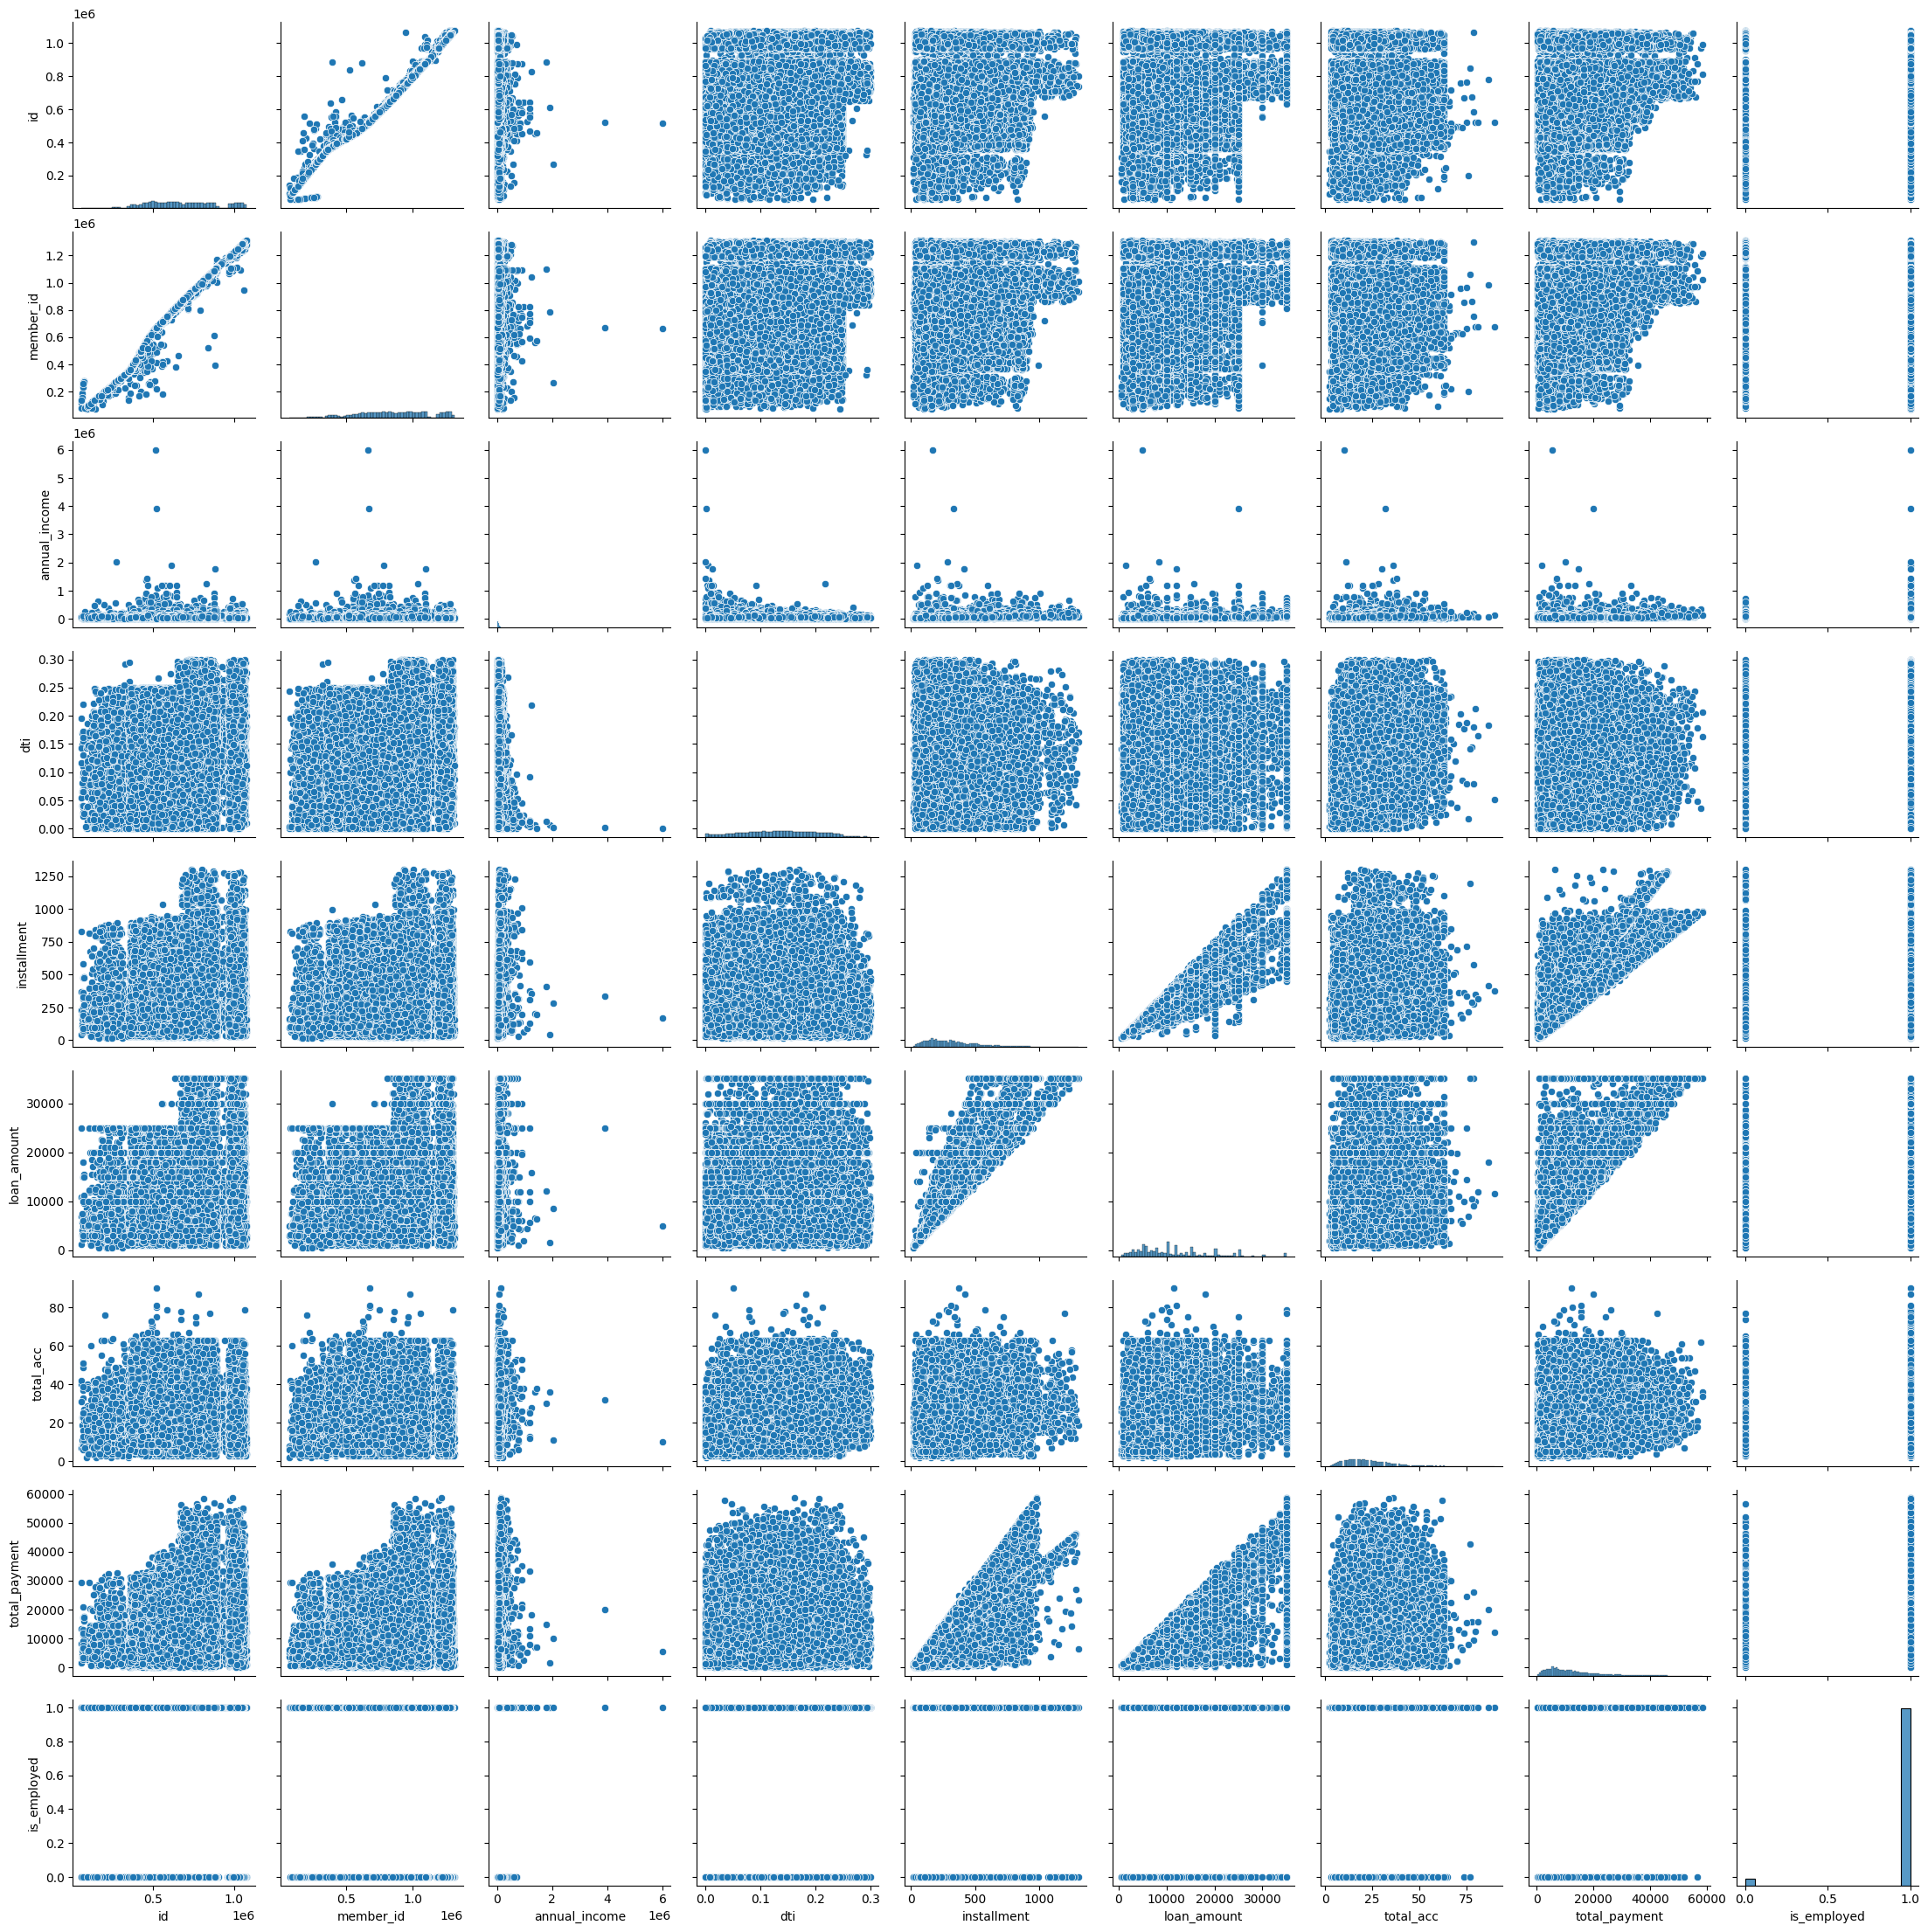

In [15]:
sns.pairplot(data)
plt.show()

# Usuwanie kolumn, pozbycie się outlierów i normalizacja

In [16]:
data = data.drop(['id', 'member_id', 'application_type'], axis=1)

id i member_id to zmienne unikalne z założenia, a application_type przyjmuje w tym przypadku tylko jedną wartość

In [17]:
data.columns

Index(['address_state', 'emp_length', 'home_ownership', 'issue_date',
       'last_credit_pull_date', 'last_payment_date', 'loan_status',
       'next_payment_date', 'purpose', 'term', 'verification_status',
       'annual_income', 'dti', 'installment', 'loan_amount', 'total_acc',
       'total_payment', 'is_employed'],
      dtype='object')

Usuwamy również zmienne mocno skorelowane ze sobą.

In [18]:
data = data.drop(['installment', 'total_payment'], axis=1) #XXX ważne do późniejszego testowania

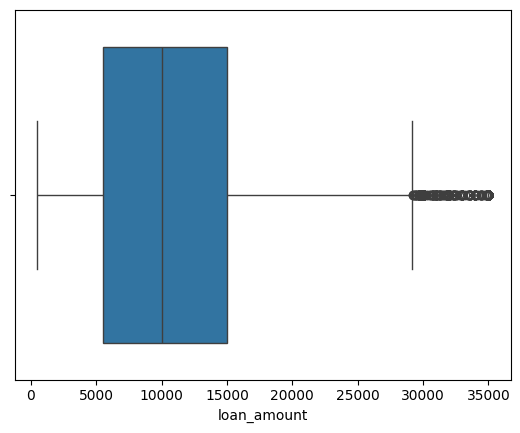

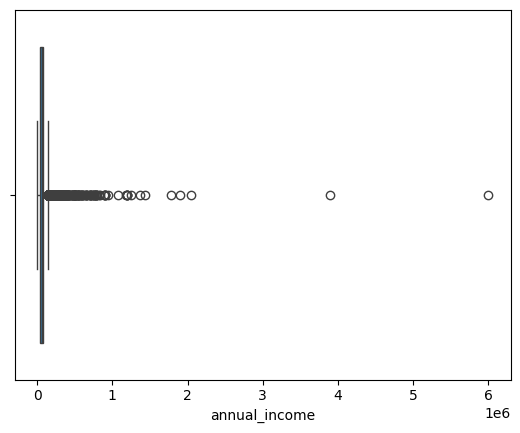

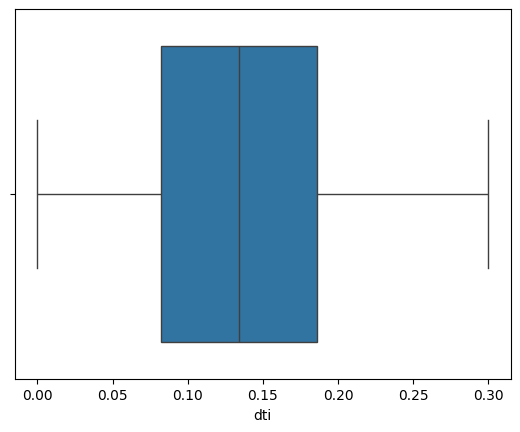

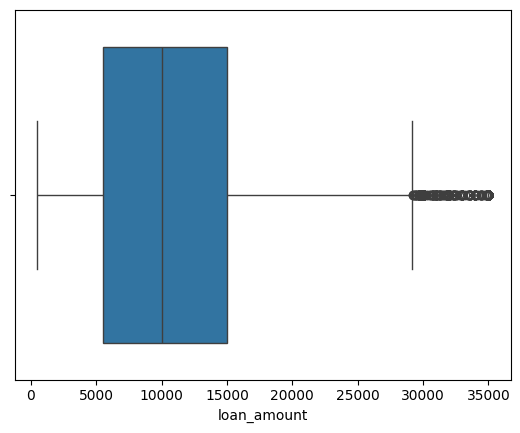

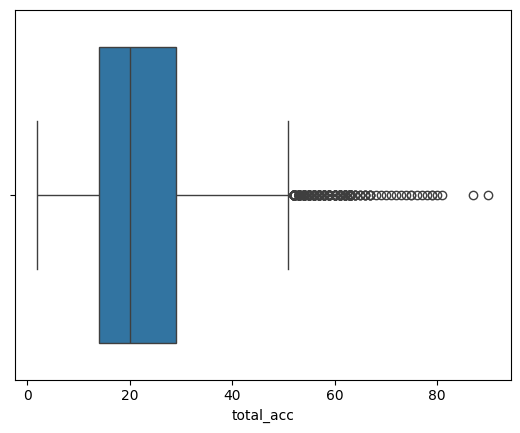

In [19]:
sns.boxplot(x=data['loan_amount'])
plt.show()
sns.boxplot(x=data['annual_income'])
plt.show()
sns.boxplot(x=data['dti'])
plt.show()
sns.boxplot(x=data['loan_amount'])
plt.show()
sns.boxplot(x=data['total_acc'])
plt.show()


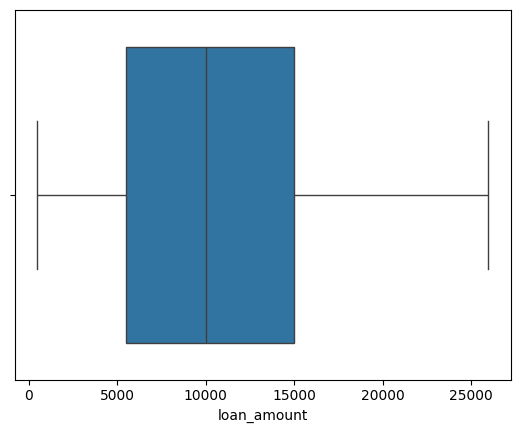

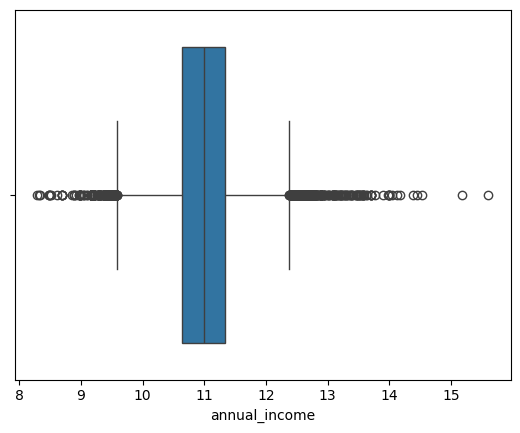

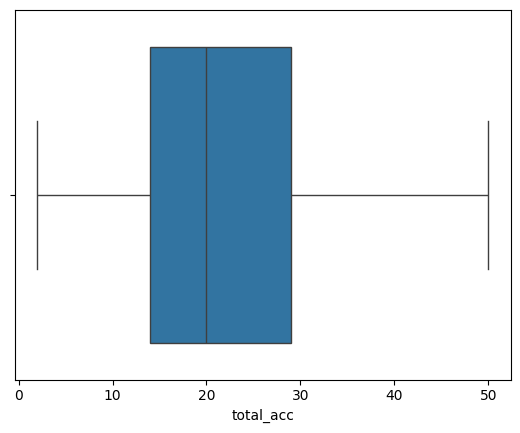

In [20]:

data['loan_amount'] = winsorize(data['loan_amount'], limits=[0, 0.04])
sns.boxplot(x=data['loan_amount'])
plt.show()
data['annual_income'] = np.log1p(data['annual_income'])
sns.boxplot(x=data['annual_income'])
plt.show()
data['total_acc'] = winsorize(data['total_acc'], limits=[0, 0.02])
sns.boxplot(x=data['total_acc'])
plt.show()


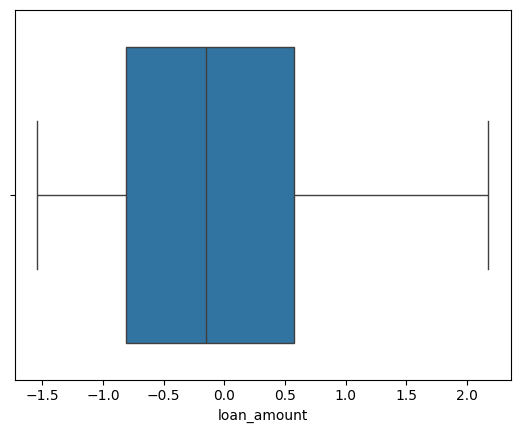

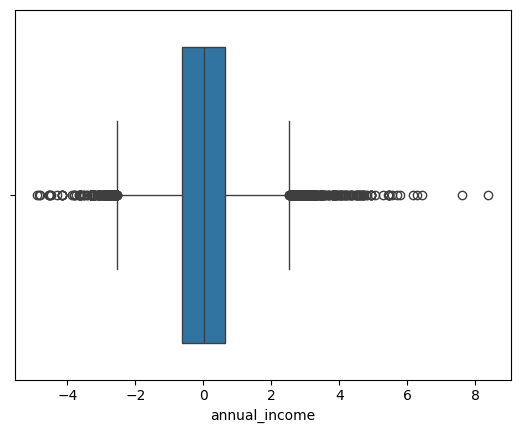

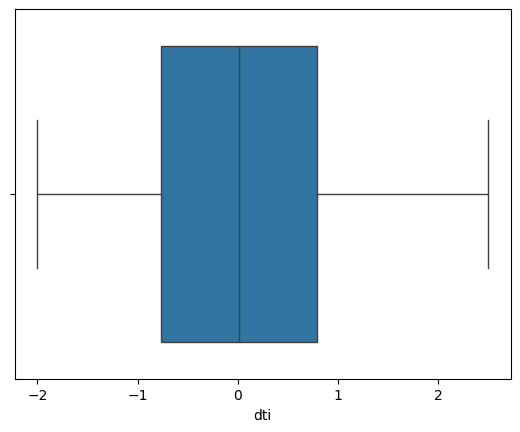

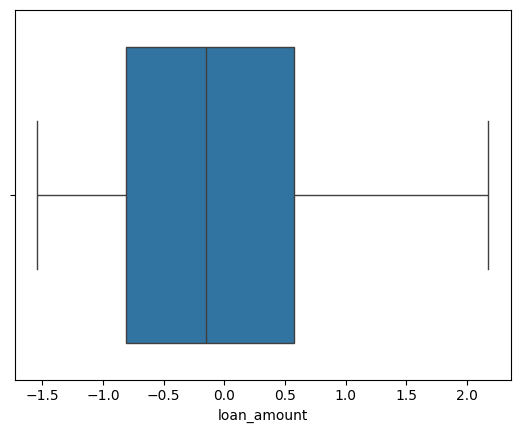

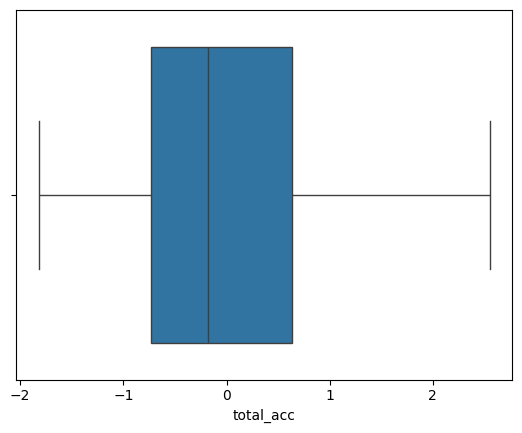

In [21]:
numeric_cols = data.select_dtypes(include=['int64', 'float64', 'int32']).columns
scaler = StandardScaler()
data[numeric_cols] = scaler.fit_transform(data[numeric_cols])
sns.boxplot(x=data['loan_amount'])
plt.show()
sns.boxplot(x=data['annual_income'])
plt.show()
sns.boxplot(x=data['dti'])
plt.show()
sns.boxplot(x=data['loan_amount'])
plt.show()
sns.boxplot(x=data['total_acc'])
plt.show()

# Kodowanie zmiennych

Zmienne kategoryczne: (one hot encoding z pominięciem jednej kolumny, zgrupowanie mniej popularnych kategorii do kategorii other, podział tematyczny na bardziej ogólne grupy)
- verification_status
- purpose
- loan_status
- address_state
- home_ownership

Zmienne porządkowe: (ordinal encoding + normalizacjia, label encoding)
- emp_length

Zmienne binarne: (binary encoding) 
- term
- is_employed

Zmienne numeryczne: (winsoryzacja, normalizacja)
- annual_income
- dti
- loan_amount
- total_acc

Zmienne reprezentujące daty:
- issue_date
- last_credit_pull_date
- last_payment_date
- next_payment_date

Dla dat możliwość liczenia odległości pomiędzy różnymi datami lub stworzenie zmiennych typu pora roku, kwartał, tydzień roku, dzień tygodnia, czy jest to weekend lub inne możliwie istotne dla tematu.

## Przetwarzanie dat

In [22]:
date_cols = ['issue_date', 'last_credit_pull_date', 'last_payment_date', 'next_payment_date']
for col in date_cols:
    data[col] = pd.to_datetime(data[col], errors='coerce', dayfirst=True)

dd = data['last_credit_pull_date']-data['issue_date']
dd_diff=[]
for i in dd:
    dd_diff.append(float(str(i).split(" ")[0]))
data['date_diff']=pd.Series(dd_diff) #różnica dni pomiędzy wydaniem kredytu a sprawdzeniem historii kredytowej

data['date_diff'] = data['date_diff'].astype(float)

data['date_diff'] = scaler.fit_transform(data[['date_diff']])

In [23]:
data = data.drop(['issue_date', 'last_credit_pull_date', 'last_payment_date', 'next_payment_date'], axis=1)

## Kodowanie

In [24]:
emp_length_order = ['< 1 year', '1 year', '2 years', '3 years', '4 years', 
                    '5 years', '6 years', '7 years', '8 years', '9 years', '10+ years']

ord_encoder = OrdinalEncoder(categories=[emp_length_order])
data[['emp_length']] = ord_encoder.fit_transform(data[['emp_length']])

In [25]:
columns = ['home_ownership', 'loan_status',
       'purpose', 'verification_status', 'purpose']
for col in columns:
    print(f"Unique values in {col}:")
    print(data[col].value_counts())
    print("\n")

Unique values in home_ownership:
home_ownership
RENT        18439
MORTGAGE    17198
OWN          2838
OTHER          98
NONE            3
Name: count, dtype: int64


Unique values in loan_status:
loan_status
Fully Paid     32145
Charged Off     5333
Current         1098
Name: count, dtype: int64


Unique values in purpose:
purpose
Debt consolidation    18214
credit card            4998
other                  3824
home improvement       2876
major purchase         2110
small business         1776
car                    1497
wedding                 928
medical                 667
moving                  559
house                   366
vacation                352
educational             315
renewable_energy         94
Name: count, dtype: int64


Unique values in verification_status:
verification_status
Not Verified       16464
Verified           12335
Source Verified     9777
Name: count, dtype: int64


Unique values in purpose:
purpose
Debt consolidation    18214
credit card            4

In [26]:
slownik = {
    'położenie': {
        'Northeast': ['CT', 'ME', 'MA', 'NH', 'RI', 'VT', 'NJ', 'NY', 'PA'],
        'Midwest': ['IL', 'IN', 'MI', 'OH', 'WI', 'IA', 'KS', 'MN', 'MO', 'NE', 'ND', 'SD'],
        'South': ['DE', 'DC', 'FL', 'GA', 'MD', 'NC', 'SC', 'VA', 'WV', 'AL', 'KY', 'MS', 'TN', 'AR', 'LA', 'OK', 'TX'],
        'West': ['AZ', 'CO', 'ID', 'MT', 'NV', 'NM', 'UT', 'WY', 'AK', 'CA', 'HI', 'OR', 'WA']
    },
    'zamożność': {
        'high': ['DC', 'MD', 'MA', 'CA', 'CO', 'NJ', 'WA', 'AK', 'VA', 'NH', 'UT', 'HI', 'CT', 'MN', 'NY', 'RI', 'DE', 'NV', 'IL', 'TX', 'AZ', 'GA', 'WI', 'OR', 'ND', 'VT', 'FL', 'NE', 'NC', 'PA', 'SD', 'IA', 'MI', 'IN', 'OH', 'SC', 'KS', 'MO', 'TN', 'ME'],
        'med': ['NM', 'ID', 'LA', 'OK', 'MT', 'KY', 'AL', 'WV', 'AR', 'MS'],
        'low': ['WY', 'NM', 'MS', 'WV', 'AR', 'AL', 'KY', 'OK', 'LA', 'SC']
    },
    'prawo_kredytowe': {
        'restrictive': ['PA', 'NY', 'CA', 'AZ', 'HI', 'IN', 'IA', 'KS', 'MT', 'NE', 'NV', 'NH', 'NJ', 'NM', 'ND', 'OH', 'OK', 'OR', 'SD', 'TN', 'UT', 'WV', 'WI', 'WY'],
        'moderate': ['DE', 'FL', 'GA', 'ID', 'IL', 'KY', 'ME', 'MD', 'MA', 'MI', 'MN', 'MO', 'NC', 'RI', 'TX', 'VT', 'VA', 'WA'],
        'lenient': ['AK', 'AL', 'AR', 'CO', 'CT', 'DC', 'LA', 'MS', 'SC', 'WI', 'WY', 'SD']
    }
}


In [27]:
# Tworzymy odwrócone słowniki dla każdej kategorii
położenie_map = {state: region for region, states in slownik['położenie'].items() for state in states}
zamożność_map = {state: zamożność for zamożność, states in slownik['zamożność'].items() for state in states}
prawo_map = {state: prawo for prawo, states in slownik['prawo_kredytowe'].items() for state in states}

# Mapowanie kolumny address_state
data['location'] = data['address_state'].map(położenie_map)
data['wealth'] = data['address_state'].map(zamożność_map)
data['law_regulations'] = data['address_state'].map(prawo_map)

In [28]:
data[['address_state', 'location', 'wealth', 'law_regulations']]

,address_state,location,wealth,law_regulations
0,GA,South,high,moderate
1,CA,West,high,restrictive
2,CA,West,high,restrictive
3,TX,South,high,moderate
4,IL,Midwest,high,moderate
...,...,...,...,...
38571,NJ,Northeast,high,restrictive
38572,NY,Northeast,high,restrictive
38573,CA,West,high,restrictive
38574,NY,Northeast,high,restrictive


In [29]:
data = pd.get_dummies(data, columns=['location', 'wealth', 'law_regulations'], drop_first=True)
data = data.drop('address_state', axis=1)

In [30]:
top_purpose = data['purpose'].value_counts().nlargest(2).index
data['purpose_grouped'] = data['purpose'].apply(lambda x: x if x in top_purpose else 'other')
data = pd.get_dummies(data, columns=['purpose_grouped'], drop_first=True)

data = data.drop('purpose', axis=1)

In [31]:
cat_cols = ['verification_status', 'loan_status', 'home_ownership']
data = pd.get_dummies(data, columns=cat_cols, drop_first=True)

bool_cols = data.select_dtypes(include='bool').columns
data[bool_cols] = data[bool_cols].astype(int)

In [32]:
data['term'] = data['term'].astype(str).str.strip()
data['60_month_term'] = np.where(data['term'] == '60 months', 1, 0)
data = data.drop('term', axis=1)


In [33]:
data.head()

,emp_length,annual_income,dti,loan_amount,total_acc,is_employed,date_diff,location_Northeast,location_South,location_West,...,purpose_grouped_other,verification_status_Source Verified,verification_status_Verified,loan_status_Current,loan_status_Fully Paid,home_ownership_NONE,home_ownership_OTHER,home_ownership_OWN,home_ownership_RENT,60_month_term
0,0.0,-1.227716,-1.849281,-1.249637,-1.638577,0.196775,1.961898,0,1,0,...,1,1,0,0,0,0,0,0,1,1
1,9.0,-0.375292,-1.196722,-1.176650,-1.638577,0.196775,2.999245,0,0,1,...,1,1,0,0,1,0,0,0,1,0
2,4.0,-0.301255,1.132987,0.137112,-1.001180,0.196775,2.952447,0,0,1,...,1,0,0,0,0,0,0,0,1,0
3,0.0,-0.617473,-1.189222,-0.957690,-1.183294,0.196775,2.554668,0,1,0,...,1,1,0,0,1,0,0,0,0,1
4,10.0,0.617947,-1.652763,-1.103663,0.546784,0.196775,2.999245,0,0,0,...,1,0,1,0,1,0,0,0,0,0


In [34]:
data.columns

Index(['emp_length', 'annual_income', 'dti', 'loan_amount', 'total_acc',
       'is_employed', 'date_diff', 'location_Northeast', 'location_South',
       'location_West', 'wealth_low', 'wealth_med', 'law_regulations_moderate',
       'law_regulations_restrictive', 'purpose_grouped_credit card',
       'purpose_grouped_other', 'verification_status_Source Verified',
       'verification_status_Verified', 'loan_status_Current',
       'loan_status_Fully Paid', 'home_ownership_NONE', 'home_ownership_OTHER',
       'home_ownership_OWN', 'home_ownership_RENT', '60_month_term'],
      dtype='object')

In [35]:
cols_to_scale = ['date_diff', 'emp_length']           
scaler = StandardScaler()
data[cols_to_scale] = scaler.fit_transform(data[cols_to_scale])

In [36]:
data.head()

,emp_length,annual_income,dti,loan_amount,total_acc,is_employed,date_diff,location_Northeast,location_South,location_West,...,purpose_grouped_other,verification_status_Source Verified,verification_status_Verified,loan_status_Current,loan_status_Fully Paid,home_ownership_NONE,home_ownership_OTHER,home_ownership_OWN,home_ownership_RENT,60_month_term
0,-1.396331,-1.227716,-1.849281,-1.249637,-1.638577,0.196775,1.961898,0,1,0,...,1,1,0,0,0,0,0,0,1,1
1,1.129782,-0.375292,-1.196722,-1.176650,-1.638577,0.196775,2.999245,0,0,1,...,1,1,0,0,1,0,0,0,1,0
2,-0.273614,-0.301255,1.132987,0.137112,-1.001180,0.196775,2.952447,0,0,1,...,1,0,0,0,0,0,0,0,1,0
3,-1.396331,-0.617473,-1.189222,-0.957690,-1.183294,0.196775,2.554668,0,1,0,...,1,1,0,0,1,0,0,0,0,1
4,1.410461,0.617947,-1.652763,-1.103663,0.546784,0.196775,2.999245,0,0,0,...,1,0,1,0,1,0,0,0,0,0


## Sprawdzanie czy zmienne prawidłowo zestandaryzowane

In [37]:
means = data.mean(axis=0)
stds = data.std(axis=0)

print("Średnie cech:", means)
print("Odchylenia standardowe cech:", stds)

Średnie cech: emp_length                            -1.178835e-16
annual_income                         -9.622240e-16
dti                                    5.304757e-17
loan_amount                           -5.894174e-17
total_acc                             -5.304757e-17
is_employed                            1.296718e-16
date_diff                             -6.630946e-18
location_Northeast                     2.452043e-01
location_South                         3.279500e-01
location_West                          2.868882e-01
wealth_low                             6.789195e-02
wealth_med                             2.203443e-03
law_regulations_moderate               4.194318e-01
law_regulations_restrictive            4.779915e-01
purpose_grouped_credit card            1.295624e-01
purpose_grouped_other                  3.982787e-01
verification_status_Source Verified    2.534477e-01
verification_status_Verified           3.197584e-01
loan_status_Current                    2.846329e-0

In [ ]:
data.to_csv('data_after_prep.csv', index=False)